In [1]:
!pip install -r ../requirements.txt

In [2]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_agent as d3qn_per_agent
import configurations.config_p1_sub5 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config_path)

device used:  cuda
device used:  cuda


<module 'configurations.config_p1_sub5' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p1_sub5.py'>

In [3]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_agent import D3QN_PER
from configurations.config_p1_sub5 import config

In [4]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=0,
    box_speed=2
)
d3qnPerAgent = D3QN_PER(env, config)

In [5]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0002, 'MAX_TRAIN_EPISODES': 500, 'MAX_EVAL_EPISODES': 1, 'updateFrequency': 500, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x00000210F88F9000>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x00000210EBA1E050>, 'max_steps': 1000, 'epsilon': 0.58, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.0012})], 'device': device(type='cuda'), 'delta': 1.0, 'tau': 0.15, 'alpha': 0.45, 'beta': 0.55, 'beta_rate': 0.0002, 'hDim': [128, 64], 'model_path': '../model_weights_phase1_sub5_v2', 'loss_fn': 'HuberLoss'}


In [6]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerAgent.runD3QN_PER()

Episode 0: TR -37200.0 | ER -992.0 | TT 11.017204523086548 | WC 19.016202688217163 | TS 1000
Episode 1: TR -4572.0 | ER -982.0 | TT 27.90863871574402 | WC 35.56183934211731 | TS 1000
Episode 2: TR -22068.0 | ER -190800.0 | TT 44.2883665561676 | WC 52.19408822059631 | TS 1000
Episode 3: TR -9184.0 | ER -187000.0 | TT 61.38516044616699 | WC 69.95242428779602 | TS 1000
Episode 4: TR -6984.0 | ER -192796.0 | TT 79.0745530128479 | WC 86.59042453765869 | TS 1000
Episode 5: TR 1242.0 | ER -200200.0 | TT 94.31044578552246 | WC 102.16572046279907 | TS 887
Episode 6: TR 1417.0 | ER -198800.0 | TT 108.79293251037598 | WC 117.26726961135864 | TS 715
Episode 7: TR -48584.0 | ER 2083.0 | TT 126.84607863426208 | WC 127.00623941421509 | TS 1000
Episode 8: TR -8468.0 | ER -1000.0 | TT 137.1290247440338 | WC 149.92711210250854 | TS 1000
Episode 9: TR -15600.0 | ER 2022.0 | TT 164.75135445594788 | WC 165.90277242660522 | TS 1000
Episode 10: TR -53000.0 | ER -1000.0 | TT 179.70210599899292 | WC 191.925074

In [7]:
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -1000.0


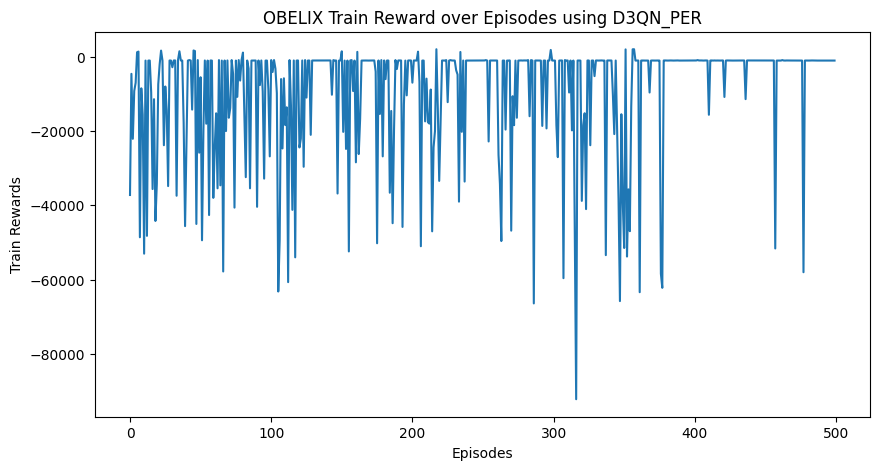

In [8]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

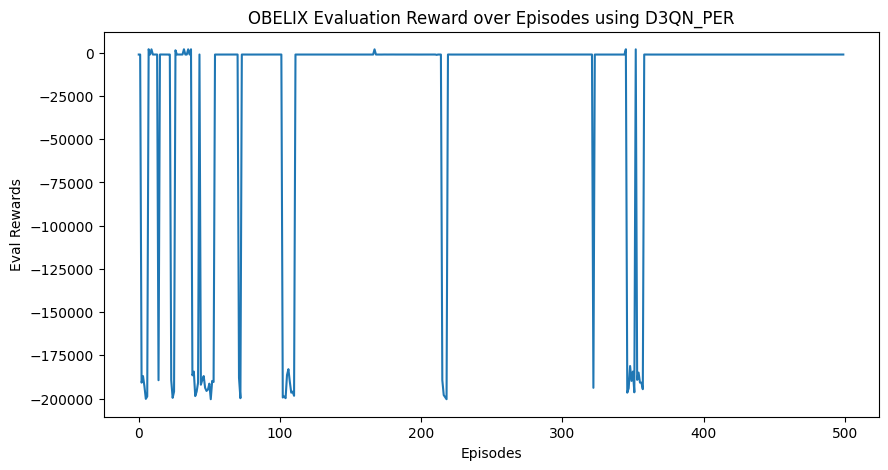

In [9]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

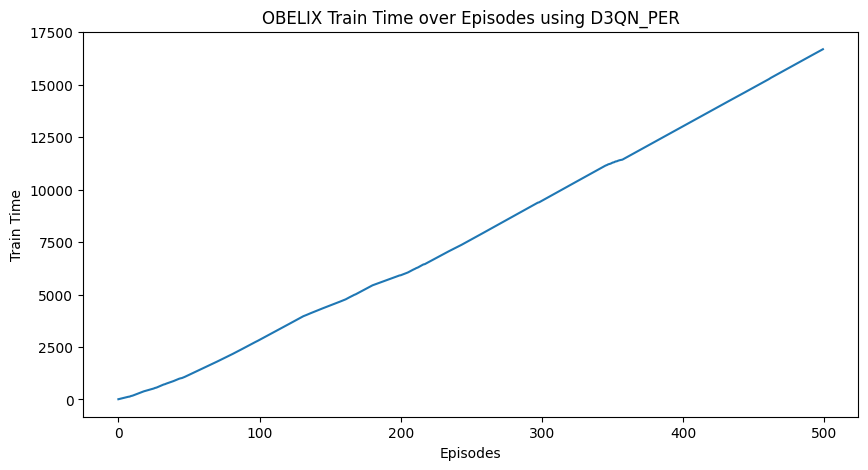

In [10]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

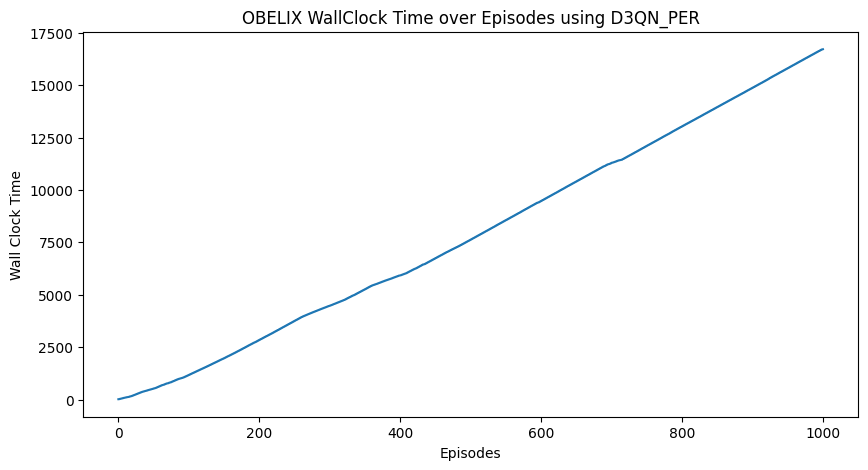

In [11]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

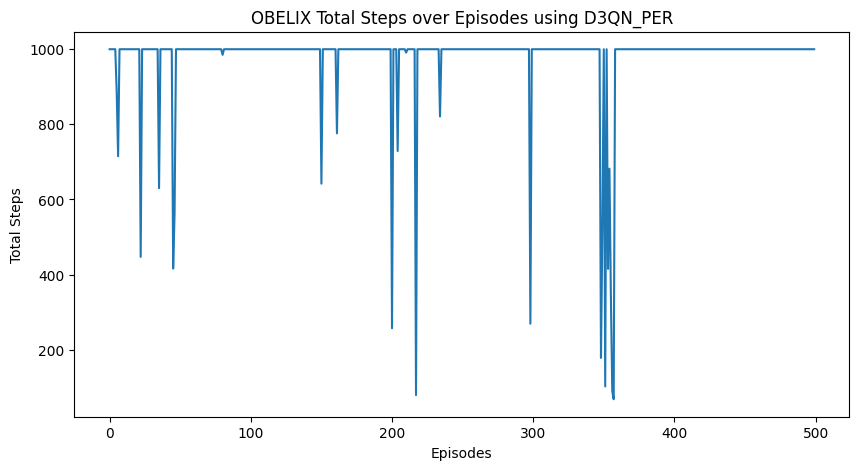

In [12]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)